# 04 – AutoML with PyCaret: NYC Citi Bike

**Worked on by:** Andreas Schellekens (PyCaret setup with yearly folds, model comparison, feature check, tuning and blending, evaluation)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant), based on `02_data_preparation.ipynb` and `03_model_baseline.ipynb`. All steps were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Setup and loading

PyCaret trains and cross-validates many model types with a few lines of code. We use it to answer two questions quickly: **which kinds of models work best for daily demand**, and **do the extra columns of 02 help them**? The answers decide which models the `05_model_*` notebooks tune by hand.

Everything follows the protocol of 03 (section 3): the same training days, target `log(demand_ratio)`, the same yearly folds, the validation year 2024 as the check, the test period once, and the same `evaluate` helper for the metrics in trips.

**Technical workaround** (as in the mushroom notebook 04, see `CLAUDE.md`): on Windows, LightGBM crashes when PyCaret is imported first. So `lightgbm` is imported **before** PyCaret, and `setup` gets `n_jobs=1` so the folds run in this process.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import json
import time
from pathlib import Path

import lightgbm  # noqa: F401  (must be imported before pycaret)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
from pycaret.regression import (blend_models, compare_models, create_model, get_config, predict_model, pull,
                                save_model, setup, tune_model)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY, "axes.titlesize": 12, "axes.titleweight": "bold",
})
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

NOTEBOOK = "04_model_automl"
RANDOM_STATE = 42
MODEL_DIR = Path("models")
MODEL_PATH = MODEL_DIR / "citibike_pycaret"  # save_model adds .pkl
METRICS_PATH = MODEL_DIR / "metrics.csv"
CV_YEARS = [2016, 2017, 2018, 2019, 2022, 2023]
with open(MODEL_DIR / "citibike_daily_dataset.json", encoding="utf-8") as file:
    DATASET = json.load(file)


def load(split):
    return pd.read_csv(DATASET["files"][split], index_col="date", parse_dates=["date"])


train, validation, test = load("train"), load("validation"), load("test")
fit_days = train[train.total > 0]  # protocol: days without trips are left out of fitting
print(f"training days with trips: {len(fit_days):,}; validation {len(validation)} days; test {len(test)} days")

training days with trips: 3,462; validation 366 days; test 607 days


## 2. The PyCaret experiment

**The data PyCaret gets.** Two feature sets:

- **base:** the inputs of the baseline (weekday, month, holiday, Christmas week, maximum temperature, precipitation class, snow on the ground), plus `tmax_c_sq`, the square of the temperature. The baseline makes that square itself (`PolynomialFeatures`); giving it to PyCaret as a column lets PyCaret's linear models draw the same curve, so the comparison is fair, and PyCaret's linear regression should reproduce our baseline.
- **extended** (section 4): base plus the extra columns of 02: `day_of_year`, the precipitation in mm, snow depth and snowfall in mm, the minimum temperature and the wind (with its gaps).

**The folds.** PyCaret accepts any object that behaves like a scikit-learn splitter. `YearlyFolds` returns exactly the folds of the protocol (03 section 3): fit on all training days before a year, predict that year, for 2016-2019 and 2022-2023. It works with row positions, so the rows must stay in date order; `data_split_shuffle=False` and `fold_shuffle=False` make sure of that, and the cell checks it.

| Setting | Value | Why |
|---|---|---|
| `data` / `test_data` | training days with trips / the validation year | PyCaret's hold-out set **is** our validation year; the test period stays outside the experiment |
| `target` | `log_ratio` = log(`demand_ratio`) | the target of the protocol |
| `categorical_features` | weekday, month, precipitation class | one-hot encoded by PyCaret |
| `normalize` | `True` | needed for linear models, KNN and SVM; trees ignore it |
| `fold_strategy` | `YearlyFolds` | time-based folds, never shuffled |
| `n_jobs` | 1 | LightGBM workaround (section 1) |

In [2]:
BASE = ["weekday", "month", "holiday", "christmas_week", "tmax_c", "precipitation", "snow_on_ground"]
EXTRA = ["day_of_year", "precipitation_mm", "snow_depth_mm", "snowfall_mm", "tmin_c", "wind_ms"]
CATEGORICAL = ["weekday", "month", "precipitation"]


def pycaret_frame(days, extra=False, with_target=True):
    frame = days[BASE + (EXTRA if extra else [])].copy()
    frame["tmax_c_sq"] = frame.tmax_c ** 2
    if with_target:
        frame["log_ratio"] = np.log(days.demand_ratio)
    return frame


class YearlyFolds:
    """Scikit-learn style splitter: fit on every day before a year, predict that year."""

    def __init__(self, index, years=CV_YEARS):
        positions = np.arange(len(index))
        self.n_rows = len(index)
        self.folds = [(positions[index.year < year], positions[index.year == year]) for year in years]

    def split(self, X=None, y=None, groups=None):
        assert X is None or len(X) == self.n_rows, "the splitter was made for other rows"
        yield from self.folds

    def get_n_splits(self, X=None, y=None, groups=None):
        return len(self.folds)


def start_experiment(extra):
    numeric = [column for column in pycaret_frame(fit_days.head(), extra).columns
               if column not in CATEGORICAL + ["log_ratio"]]
    setup(data=pycaret_frame(fit_days, extra), test_data=pycaret_frame(validation, extra), target="log_ratio",
          categorical_features=CATEGORICAL, numeric_features=numeric, numeric_imputation="median",
          normalize=True, fold_strategy=YearlyFolds(fit_days.index), data_split_shuffle=False, fold_shuffle=False,
          session_id=RANDOM_STATE, n_jobs=1, verbose=False, html=False)
    assert get_config("X_train").index.equals(fit_days.index), "PyCaret changed the order of the training days"
    assert get_config("X_test").index.equals(validation.index)
    return numeric


numeric_base = start_experiment(extra=False)
print("numeric:", numeric_base, "| categorical:", CATEGORICAL)
print("columns after PyCaret's encoding:", get_config("X_train_transformed").shape[1])

numeric: ['holiday', 'christmas_week', 'tmax_c', 'snow_on_ground', 'tmax_c_sq'] | categorical: ['weekday', 'month', 'precipitation']
columns after PyCaret's encoding: 29


## 3. Comparing all model types (base features)

`compare_models` trains every regression model PyCaret knows with default settings and scores it on the yearly folds. The errors are on the log scale of the ratio: a mean absolute error (MAE) of 0.15 means the prediction is off by about 15% on a typical day. We sort on MAE, the scoring of the protocol. PyCaret's `MAPE` column is a percentage of the **log ratio**, not of the trips, so it is meaningless here and we ignore it. XGBoost and CatBoost are not installed; LightGBM and scikit-learn's gradient boosting cover boosting.

In [3]:
start = time.time()
top_base = compare_models(sort="MAE", n_select=5, verbose=False)
comparison_base = pull()
print(f"compare_models took {time.time() - start:.0f} s")
comparison_base.drop(columns=["MAPE"])

compare_models took 26 s


,Model,MAE,MSE,RMSE,R2,RMSLE,TT (Sec)
gbr,Gradient Boosting Regressor,0.1536,0.0548,0.2310,0.7761,0.1356,0.2717
huber,Huber Regressor,0.1571,0.0540,0.2310,0.7794,0.1358,0.1150
lightgbm,Light Gradient Boosting Machine,0.1588,0.0572,0.2370,0.7637,0.1394,0.1567
rf,Random Forest Regressor,0.1678,0.0632,0.2496,0.7389,0.1469,0.7833
lr,Linear Regression,0.1683,0.0568,0.2371,0.7626,0.1395,0.1000
ridge,Ridge Regression,0.1683,0.0568,0.2370,0.7625,0.1395,0.1033
br,Bayesian Ridge,0.1692,0.0575,0.2382,0.7593,0.1401,0.1067
et,Extra Trees Regressor,0.1890,0.0833,0.2870,0.6521,0.1624,0.7550
knn,K Neighbors Regressor,0.1928,0.0879,0.2903,0.6342,0.1659,0.1367
dt,Decision Tree Regressor,0.2254,0.1159,0.3386,0.5034,0.1889,0.1067


**Interpretation**

- **Boosting comes first:** gradient boosting (MAE 0.154 on the log scale) and LightGBM (0.159) are in the top three. Trees can combine features ("cold **and** wet **and** a Sunday") and draw any curve for the temperature, which a linear model cannot.
- **A robust linear model is second:** the Huber regressor (0.157) beats ordinary linear regression (0.168, our baseline) clearly. Huber uses the squared error for small residuals but only the absolute error for large ones, so extreme days (the lockdown of 2020, storms, holidays) pull less on its coefficients. That it wins shows that a few extreme days distort the baseline.
- The random forest (0.168) is no better than linear regression on these features; extra trees, KNN and a single decision tree are worse.
- **Lasso, elastic net and Lasso-LARS score exactly like the dummy model** (0.387, always predicting the mean). That does not mean the features are useless: PyCaret's default penalty (`alpha=1`) is far too strong for a target with a spread of about 0.5, so every coefficient is set to 0.
- The differences within the top three (0.154-0.159) are small, so the ranking among them is not certain.

Two checks follow. First, PyCaret's linear regression must give the same predictions as our baseline of 03, otherwise the two notebooks would not measure the same thing. Then the top five are scored on the validation year **in trips**, with the `evaluate` helper of 03, to see whether the ranking of the folds holds on unseen data.

In [4]:
def evaluate(name, split, actual, predicted):
    """Metrics in trips for one model on one set; MAPE-type metrics only on days with trips (03 section 3)."""
    error = predicted - actual
    has_trips = actual > 0
    percentage = error[has_trips] / actual[has_trips] * 100
    return {
        "model": name, "notebook": NOTEBOOK, "split": split, "days": len(actual),
        "mae": error.abs().mean(), "rmse": np.sqrt((error ** 2).mean()),
        "mape": percentage.abs().mean(), "median_ape": percentage.abs().median(),
        "within_20pct": (percentage.abs() <= 20).mean() * 100, "bias_pct": percentage.mean(),
    }


def predict_trips(model, days, extra=False):
    log_ratio = predict_model(model, data=pycaret_frame(days, extra, with_target=False), verbose=False).prediction_label
    return pd.Series(np.exp(log_ratio.to_numpy()) * days.level_12m.to_numpy(), index=days.index)


baseline = joblib.load(MODEL_DIR / "citibike_baseline.joblib")
pycaret_lr = create_model("lr", verbose=False)
difference = np.abs(predict_model(pycaret_lr, data=pycaret_frame(validation, with_target=False), verbose=False)
                    .prediction_label.to_numpy() - baseline.predict(validation[BASE]))
print(f"PyCaret linear regression vs. baseline on the validation year: largest difference "
      f"{difference.max():.4f} on the log scale ({(np.exp(difference.max()) - 1) * 100:.1f}%)")

names_base = comparison_base.index[:5]
pd.DataFrame([evaluate(comparison_base.loc[name, "Model"], "validation", validation.total,
                       predict_trips(model, validation)) for name, model in zip(names_base, top_base)]
             ).drop(columns=["notebook", "split", "days"]).set_index("model").round(1)

PyCaret linear regression vs. baseline on the validation year: largest difference 0.0246 on the log scale (2.5%)


,mae,rmse,mape,median_ape,within_20pct,bias_pct
model,,,,,,
Gradient Boosting Regressor,11223.1,14084.7,11.1,8.4,84.4,-4.6
Huber Regressor,10768.1,14496.0,11.2,7.1,88.3,-1.0
Light Gradient Boosting Machine,10916.1,14004.6,11.8,7.5,81.4,-4.1
Random Forest Regressor,12900.3,16848.9,13.5,9.2,79.5,-2.2
Linear Regression,12764.2,16692.1,12.4,9.7,83.1,-4.1


**Interpretation**

- **PyCaret's linear regression is our baseline:** the predictions differ by at most 0.9% (PyCaret encodes and scales the columns in its own way; with one-hot columns that add up to a constant the solution is not unique, and the numerics differ slightly), and the validation MAE is 12,817 against 12,787 trips. Both notebooks measure the same thing.
- **The validation year confirms the ranking of the folds**: gradient boosting MAPE 11.1%, Huber 11.2%, LightGBM 11.8%, linear regression 12.4%, random forest 13.5%. The three best are all clearly better than the baseline.
- The Huber regressor has the lowest MAE (10,768 trips), the lowest median error (7.1%) and almost no bias (-1.0%): a linear model with a robust loss is a serious, explainable candidate for the next notebooks.

## 4. Do the extra columns help?

02 (section 7) found that the extra weather columns hardly help a **linear** model. Tree models can use them differently: they can split on snow depth as a number, combine the rain in mm with the temperature, or use the day of the year for holidays and seasons. We repeat the comparison with the extended feature set; PyCaret fills the wind gaps with the median of the training days (learned on train only).

In [5]:
numeric_extended = start_experiment(extra=True)
start = time.time()
top_extended = compare_models(sort="MAE", n_select=3, verbose=False)
comparison_extended = pull()
print(f"compare_models took {time.time() - start:.0f} s")
side_by_side = pd.DataFrame({"base MAE": comparison_base.set_index("Model")["MAE"],
                             "extended MAE": comparison_extended.set_index("Model")["MAE"]})
side_by_side["change"] = side_by_side["extended MAE"] - side_by_side["base MAE"]
side_by_side.sort_values("extended MAE").round(4)

compare_models took 36 s


,base MAE,extended MAE,change
Model,,,
Gradient Boosting Regressor,0.1536,0.1404,-0.0132
Random Forest Regressor,0.1678,0.1465,-0.0213
Light Gradient Boosting Machine,0.1588,0.1500,-0.0088
Huber Regressor,0.1571,0.1517,-0.0054
Extra Trees Regressor,0.1890,0.1569,-0.0321
Linear Regression,0.1683,0.1600,-0.0083
Ridge Regression,0.1683,0.1602,-0.0081
Bayesian Ridge,0.1692,0.1615,-0.0077
K Neighbors Regressor,0.1928,0.1880,-0.0048


**Interpretation**

- **The extra columns help almost every model, and the tree models most:** extra trees -0.032, random forest -0.021, gradient boosting -0.013, LightGBM -0.009 on the log scale; the linear models gain less (-0.008, Huber -0.005), as 02 (section 7) found for a linear model.
- **Gradient boosting stays first** (0.140), the random forest moves up to second (0.147), LightGBM third (0.150). Section 7 shows which of the new columns the trees use.
- **Least Angle Regression breaks down** (0.168 to 0.491): it is numerically unstable when columns are strongly correlated, as the maximum and minimum temperature, the squared temperature and the day of the year are. That is a weakness of the algorithm, not of the data; the other linear models are fine.
- Lasso, elastic net and Lasso-LARS are still equal to the dummy model (same reason as in section 3).

**Decision:** the rest of this notebook uses the extended feature set.

## 5. Can PyCaret improve the best model automatically?

Two cheap improvements, on the extended feature set:

- **`tune_model`**: a random search (30 combinations) over PyCaret's predefined space for the best model, optimising MAE on the same yearly folds. `choose_better=False`, so we see what tuning really does (by default PyCaret silently returns the original model when tuning makes it worse).
- **`blend_models`**: the average of the predictions of the top three models.

Each candidate is judged on the folds (the protocol's choice) and checked on the validation year in trips.

In [6]:
def fold_mae():
    return pull().loc["Mean", "MAE"]


best_name = comparison_extended.index[0]
candidates = {f"{best_name} (default)": (top_extended[0], comparison_extended.loc[best_name, "MAE"])}
start = time.time()
tuned = tune_model(top_extended[0], optimize="MAE", n_iter=30, choose_better=False, verbose=False)
candidates[f"{best_name} (PyCaret-tuned)"] = (tuned, fold_mae())
blend = blend_models(top_extended, verbose=False)
candidates["blend " + " + ".join(comparison_extended.index[:3])] = (blend, fold_mae())
print(f"tuning and blending took {time.time() - start:.0f} s")

rows = []
for name, (model, mae) in candidates.items():
    row = evaluate(name, "validation", validation.total, predict_trips(model, validation, extra=True))
    rows.append({"model": name, "folds MAE (log)": mae, "validation MAE (trips)": row["mae"],
                 "validation MAPE": row["mape"], "validation within 20%": row["within_20pct"],
                 "validation bias": row["bias_pct"]})
improvement = pd.DataFrame(rows).set_index("model")
improvement.round({"folds MAE (log)": 4, "validation MAE (trips)": 0, "validation MAPE": 1,
                   "validation within 20%": 1, "validation bias": 1})

tuning and blending took 80 s


,folds MAE (log),validation MAE (trips),validation MAPE,validation within 20%,validation bias
model,,,,,
gbr (default),0.1404,10345.0,10.2,89.1,-3.2
gbr (PyCaret-tuned),0.1402,9923.0,9.9,88.0,-3.7
blend gbr + rf + lightgbm,0.1381,9658.0,9.5,88.5,-3.1


**Interpretation**

- **Tuning hardly changes gradient boosting on the folds** (MAE 0.1404 to 0.1402) and helps a little on the validation year (MAPE 10.2% to 9.9%). PyCaret's search chose a slower learning rate (0.05) with more trees (270), deeper trees (depth 6), and random subsets of rows (70%) and columns (`sqrt`). Unlike for the mushrooms, PyCaret's search space did not hurt here, but it did not help much either.
- **The blend of gradient boosting, random forest and LightGBM is the best on the folds** (0.1381) and on the validation year (MAPE 9.5%, MAE 9,658 trips). The three are all tree ensembles, but built differently (boosting of small trees, averaging of deep trees, leaf-wise boosting); averaging them cancels part of their separate errors.
- The validation year agrees with the folds on the order of the three candidates.

**Decision:** following the protocol, the candidate with the lowest error on the folds, the **blend**, is PyCaret's model for the comparison. The price is size and speed (three models, one of them a forest); for the deployment a single model may be the better trade-off, which the `05` notebooks will weigh.

In [7]:
chosen_name = improvement["folds MAE (log)"].idxmin()  # protocol: the choice is made on the folds
chosen = candidates[chosen_name][0]
print("chosen on the folds:", chosen_name)
if hasattr(tuned, "get_params"):
    keys = ["n_estimators", "learning_rate", "max_depth", "num_leaves", "min_samples_leaf", "min_child_samples",
            "subsample", "max_features"]
    print("hyperparameters of the PyCaret-tuned model:", {key: value for key, value in tuned.get_params().items() if key in keys})

chosen on the folds: blend gbr + rf + lightgbm
hyperparameters of the PyCaret-tuned model: {'learning_rate': 0.05, 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 270, 'subsample': 0.7}


## 6. Validation and test

The chosen model is evaluated on the validation year and **once** on the test period, next to the baseline of 03 on the same days. The test period contains one day without trips (23 February 2026); it only counts in the MAE and RMSE.

In [8]:
predictions = {split: predict_trips(chosen, days, extra=True) for split, days in [("validation", validation), ("test", test)]}
baseline_predictions = {split: pd.Series(np.exp(baseline.predict(days[BASE])) * days.level_12m, index=days.index)
                        for split, days in [("validation", validation), ("test", test)]}
results, comparison_rows = [], []
for split, days in [("validation", validation), ("test", test)]:
    results.append(evaluate(f"PyCaret {chosen_name}", split, days.total, predictions[split]))
    comparison_rows.append(evaluate("baseline (03)", split, days.total, baseline_predictions[split]))
pd.DataFrame(comparison_rows + results).drop(columns="notebook").set_index(["model", "split"]).sort_index(
    level="split", sort_remaining=False).round(1)

,,days,mae,rmse,mape,median_ape,within_20pct,bias_pct
model,split,,,,,,,
baseline (03),test,607,17205.6,22336.1,17.4,11.9,73.6,7.8
PyCaret blend gbr + rf + lightgbm,test,607,13806.2,17529.1,14.6,9.8,80.9,8.6
baseline (03),validation,366,12787.6,16670.3,12.4,9.7,82.2,-4.2
PyCaret blend gbr + rf + lightgbm,validation,366,9657.7,12700.3,9.5,6.3,88.5,-3.1


**Interpretation**

- **Validation 2024:** MAPE 9.5% against 12.4% for the baseline, MAE 9,658 against 12,787 trips (24% lower), 88.5% of the days within 20% (baseline 82.2%).
- **Test 2025-2026 (reported once):** MAPE 14.6% against 17.4%, MAE 13,806 against 17,206 trips (20% lower), 80.9% of the days within 20% (73.6%).
- **But the bias is not smaller:** +8.6% on the test period (baseline +7.8%). The PyCaret model reacts better to the weather of the day, but it shares the drift of the level that 03 found. On the one day without trips (23 February 2026, a blizzard) it predicts about 5,000 trips: it recognises the storm, it only cannot know that the system was closed.

Does the better model also fix the drift over time that 03 found? The chart shows the mean signed error per month for both models.

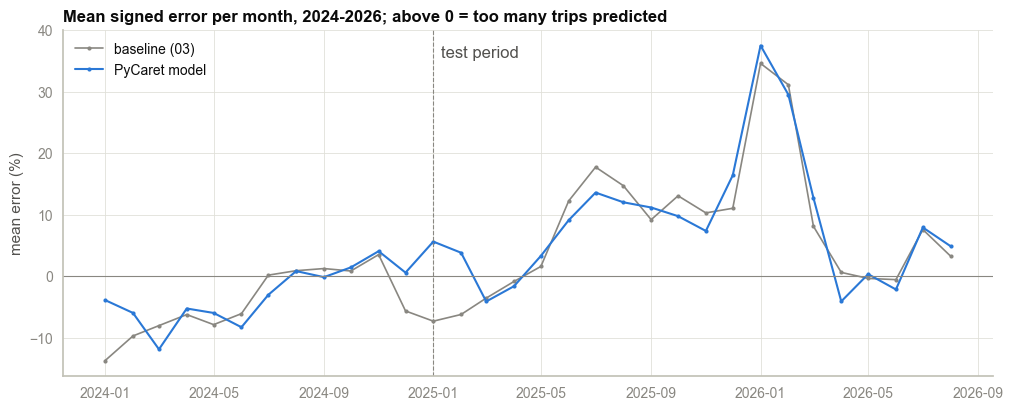

date,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,...,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01,2026-08-01
baseline (03),-13.7,-9.7,-8.0,-6.2,-7.8,-6.1,0.2,0.9,1.3,0.9,...,10.3,11.0,34.6,31.1,8.1,0.6,-0.3,-0.5,7.6,3.3
PyCaret model,-3.9,-5.9,-11.9,-5.2,-6.0,-8.3,-3.0,0.8,-0.1,1.4,...,7.4,16.4,37.5,29.5,12.7,-4.1,0.3,-2.1,7.9,4.9


In [9]:
def monthly_bias(predicted, days):
    percentage = ((predicted - days.total) / days.total * 100)[days.total > 0]
    return percentage.resample("MS").mean()


hold_out = pd.concat([validation, test])
bias = pd.DataFrame({
    "baseline (03)": monthly_bias(pd.concat(baseline_predictions.values()), hold_out),
    "PyCaret model": monthly_bias(pd.concat(predictions.values()), hold_out),
})
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(bias.index, bias["baseline (03)"], color=INK_MUTED, marker="o", markersize=3, linewidth=1.2,
        label="baseline (03)")
ax.plot(bias.index, bias["PyCaret model"], color=BLUE, marker="o", markersize=3, linewidth=1.5,
        label="PyCaret model")
ax.axvline(pd.Timestamp("2025-01-01"), color=INK_MUTED, linewidth=0.8, linestyle="--")
ax.text(pd.Timestamp("2025-01-10"), bias.max().max(), "test period", color=INK_SECONDARY, va="top")
ax.axhline(0, color=INK_MUTED, linewidth=0.8)
ax.set_ylabel("mean error (%)")
ax.set_title("Mean signed error per month, 2024-2026; above 0 = too many trips predicted", loc="left")
ax.legend(loc="upper left", frameon=False)
plt.show()
bias.round(1).T

**Interpretation:** the errors per month have the same shape as the baseline's, only a little smaller in some months.

- 2024: too low in the first half (-4% to -12% per month), about right from July.
- 2025: too high from June (+9% to +16% per month; baseline +9% to +18%), when growth stopped.
- January and February 2026: +37.5% and +29.5% (baseline +34.5% and +31.1%). Deep snow is not new to the model: the training years have 104 days with at least 100 mm of snow on the ground. December 2025 was already 16% too high, so a large part of these errors is the same drift as in late 2025, on top of a hard winter.

So the drift is **not** a problem of the model type: three very different models (linear, boosting, forest) make the same monthly errors. It comes from the target: the level of the previous months and the ratio the models learned in years of growth. A better model of the daily weather cannot fix it; a feature that tells the model how fast the system is growing right now could.

## 7. What does the model look at?

For tree ensembles PyCaret can show the impurity-based feature importance: how much each column reduces the squared error over all splits. If the chosen model is a blend, we show the importance of its first tree member. A caveat (as with the mushrooms): this measure favours numerical columns with many possible split points over 0/1 columns, so it shows what the trees use, not a causal effect.

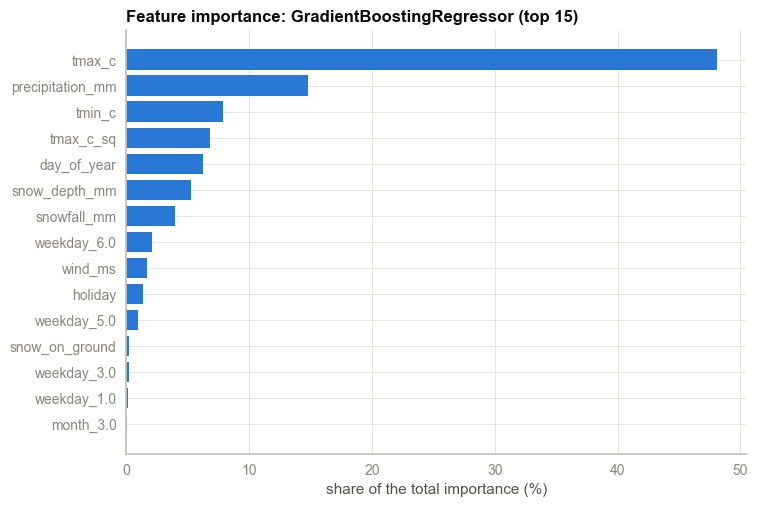

In [10]:
members = chosen.estimators_ if hasattr(chosen, "estimators_") else [chosen]
tree_model = next(member for member in members if hasattr(member, "feature_importances_"))
columns = get_config("X_train_transformed").columns
importance = pd.Series(tree_model.feature_importances_, index=columns)
importance = (importance / importance.sum() * 100).sort_values().tail(15)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(importance.index, importance.values, color=BLUE)
ax.set_xlabel("share of the total importance (%)")
ax.set_title(f"Feature importance: {type(tree_model).__name__} (top 15)", loc="left")
plt.show()

**Interpretation**

- **Temperature dominates:** the maximum temperature (48%), its square (7%) and the minimum temperature (8%) together have about 60% of the importance. Temperature drives both the season and the day-to-day differences in the ratio.
- **The precipitation in mm** (15%) is the second feature. It is more detailed than the five classes, which the trees do not need any more; together with **snow depth** (5%) and **snowfall** (4%) in mm, this explains why the extended columns help the trees (section 4). The yes/no snow flag drops to almost 0: snow depth contains the same information and more.
- `day_of_year` (6%) replaces the month columns, which hardly appear: a tree can split the year at any day.
- Sunday and Saturday, the wind and the holiday flag follow; the other weekdays matter little, as in the baseline's coefficients (03 section 7).

## 8. Saving the model and the metrics

`save_model` stores PyCaret's whole pipeline (imputation, encoding, scaling and the model) as one `.pkl` file. As with the mushrooms, we do **not** use `finalize_model`: it would retrain on train **and** the validation year, and then the validation year could no longer compare the models fairly. The PyCaret model is saved for the comparison notebook, not for deployment: loading it needs PyCaret in the API. The deployed model will be a plain scikit-learn pipeline (the baseline now, a tuned model from `05` later).

In [11]:
save_model(chosen, str(MODEL_PATH), verbose=False)
size_mb = MODEL_PATH.with_suffix(".pkl").stat().st_size / 1e6
print(f"saved {MODEL_PATH.with_suffix('.pkl')} ({size_mb:.1f} MB)")

new_rows = pd.DataFrame(results)
metrics = pd.read_csv(METRICS_PATH)
metrics = pd.concat([metrics[metrics.notebook != NOTEBOOK], new_rows], ignore_index=True)
metrics.to_csv(METRICS_PATH, index=False)
metrics.drop(columns="notebook").round(1)

saved models\citibike_pycaret.pkl (32.0 MB)


,model,split,days,mae,rmse,mape,median_ape,within_20pct,bias_pct
0,gradient boosting (05a),validation,366,9499.5,12207.3,9.6,6.4,86.1,-3.1
1,gradient boosting (05a),test,607,14577.8,18235.1,15.1,10.4,80.0,8.8
2,Huber regression (05b),validation,366,11645.3,15293.6,10.8,8.7,88.3,-2.7
3,Huber regression (05b),test,607,15837.4,20535.3,15.7,11.2,77.9,9.4
4,ensemble 05a + 05b (05c),validation,366,9712.1,12667.1,9.3,6.8,90.2,-3.1
5,ensemble 05a + 05b (05c),test,607,14363.4,18112.8,14.4,10.2,81.4,8.8
6,seasonal naive,validation,366,17755.7,24079.1,22.2,10.9,71.9,5.2
7,linear regression (baseline),validation,366,12787.6,16670.3,12.4,9.7,82.2,-4.2
8,seasonal naive,test,607,24128.1,32296.4,38.0,14.7,61.9,31.6
9,linear regression (baseline),test,607,17205.6,22336.1,17.4,11.9,73.6,7.8


## 9. Conclusion and next steps

- **Best model types for daily demand:** boosting (gradient boosting, LightGBM), followed by a robust linear model (Huber) and, with the extended columns, the random forest. Ordinary linear regression, PyCaret's version of our baseline, is in the middle; KNN, single trees and AdaBoost are worse.
- **The extra columns of 02 help the tree models** (precipitation and snow in mm, minimum temperature, day of the year); linear models gain little from them.
- **PyCaret's model:** a blend of gradient boosting, random forest and LightGBM, chosen on the folds. Validation MAPE 9.5% (baseline 12.4%), test MAPE 14.6% (baseline 17.4%), MAE about 20-24% lower than the baseline.
- **Not solved:** the drift over time (test bias +8.6%). It is the same for every model type, so it must be tackled in the features or the target, not by a better algorithm.
- Saved as `models/citibike_pycaret.pkl` (32 MB, git-ignored and regenerated by this notebook, like the mushroom PyCaret model); not meant for deployment.

**Plan for the `05` notebooks** (protocol of 03, extended features):

- A hand-tuned **gradient boosting** model (scikit-learn's `HistGradientBoostingRegressor`, which handles the wind gaps natively and is small enough to deploy, or LightGBM).
- A second model family: a **random forest**, or the **Huber regressor** as an explainable, robust linear model.
- Candidate features against the drift and the big misses of 03: the **recent growth** of the system (the last published months against the same months a year earlier), separate effects for the **big holidays** (Thanksgiving and the day after, Christmas, New Year's Day), and possibly more weight for recent training years.